# Case Study: Supply Chain and Inventory Management
## ABC Supermarket — Data-Driven Inventory Optimisation

### Background
ABC Supermarket operates across multiple cities and has been struggling with stock imbalances —
some products run out too quickly (stockouts) while others remain unsold for months (overstocking),
increasing costs and reducing profits.

Management has decided to use data-driven insights to optimise inventory and supply chain operations.

### Problem Statement
1. **Balance stock levels** — ensure products are neither understocked nor overstocked
2. **Improve demand forecasting** — use historical sales data to predict future demand
3. **Optimise reorder strategies** — automate when and how much to reorder
4. **Reduce waste and carrying costs** — minimise holding costs while maintaining availability

### Tools Used
| Section | Tools |
|---|---|
| SQL Analytics | SQLite (MySQL syntax shown) |
| Forecasting & Optimisation | Pandas, NumPy, Matplotlib, Scikit-Learn |
| Data Warehousing | Pandas, SQLite |


## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
from datetime import timedelta
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# Load datasets
sales_df           = pd.read_csv('sales_data-2.csv')
inventory_df       = pd.read_csv('inventory_data.csv')
suppliers_df       = pd.read_csv('suppliers_data.csv')
purchase_orders_df = pd.read_csv('purchase_orders_data.csv')

# Parse dates
sales_df['Sale_Date']              = pd.to_datetime(sales_df['Sale_Date'])
inventory_df['Last_Updated']       = pd.to_datetime(inventory_df['Last_Updated'])
purchase_orders_df['Order_Date']   = pd.to_datetime(purchase_orders_df['Order_Date'])
purchase_orders_df['Arrival_Date'] = pd.to_datetime(purchase_orders_df['Arrival_Date'])

print("Datasets loaded successfully.")
print(f"\n{'Dataset':<22} {'Rows':>8}  {'Cols':>6}")
print("-" * 40)
for name, df in [('Sales', sales_df), ('Inventory', inventory_df),
                  ('Suppliers', suppliers_df), ('Purchase Orders', purchase_orders_df)]:
    print(f"  {name:<20} {len(df):>8,}  {df.shape[1]:>6}")
print(f"\nSales date range: {sales_df['Sale_Date'].min().date()} to {sales_df['Sale_Date'].max().date()}")


Datasets loaded successfully.

Dataset                    Rows    Cols
----------------------------------------
  Sales                   5,000       6
  Inventory                 200       6
  Suppliers                  50       5
  Purchase Orders         1,000       6

Sales date range: 2024-01-01 to 2037-09-08


In [3]:
# Preview each dataset
for name, df in [('SALES', sales_df), ('INVENTORY', inventory_df),
                  ('SUPPLIERS', suppliers_df), ('PURCHASE ORDERS', purchase_orders_df)]:
    print("=" * 65)
    print(f"  {name}")
    print("=" * 65)
    display(df.head(3))
    print(f"  Shape: {df.shape}  |  Nulls: {df.isnull().sum().sum()}")
    print()


  SALES


,Sale_ID,Product_ID,Store_ID,Sale_Date,Quantity_Sold,Revenue
0,0d12b607,P001,S102,2024-01-01,322,2556
1,2e13fe47,P003,S101,2024-01-02,28,42606
2,c05afd2d,P003,S104,2024-01-03,292,19551


  Shape: (5000, 6)  |  Nulls: 0

  INVENTORY


,Product_ID,Store_ID,Warehouse_ID,Stock_Level,Reorder_Level,Last_Updated
0,P005,S101,W003,498,163,2024-02-01
1,P004,S103,W003,24,178,2024-02-02
2,P002,S101,W002,245,188,2024-02-03


  Shape: (200, 6)  |  Nulls: 0

  SUPPLIERS


,Supplier_ID,Supplier_Name,Product_ID,Lead_Time (days),Order_Frequency
0,SUP001,Murray-Ramirez,P002,9,Weekly
1,SUP002,"Thomas, Meyer and Campbell",P005,9,Weekly
2,SUP003,Acosta Inc,P005,4,Monthly


  Shape: (50, 5)  |  Nulls: 0

  PURCHASE ORDERS


,Order_ID,Product_ID,Supplier_ID,Order_Date,Quantity,Arrival_Date
0,PO0001,P001,SUP002,2024-01-01,158,2024-01-06
1,PO0002,P005,SUP019,2024-01-02,440,2024-01-07
2,PO0003,P002,SUP036,2024-01-03,423,2024-01-08


  Shape: (1000, 6)  |  Nulls: 0



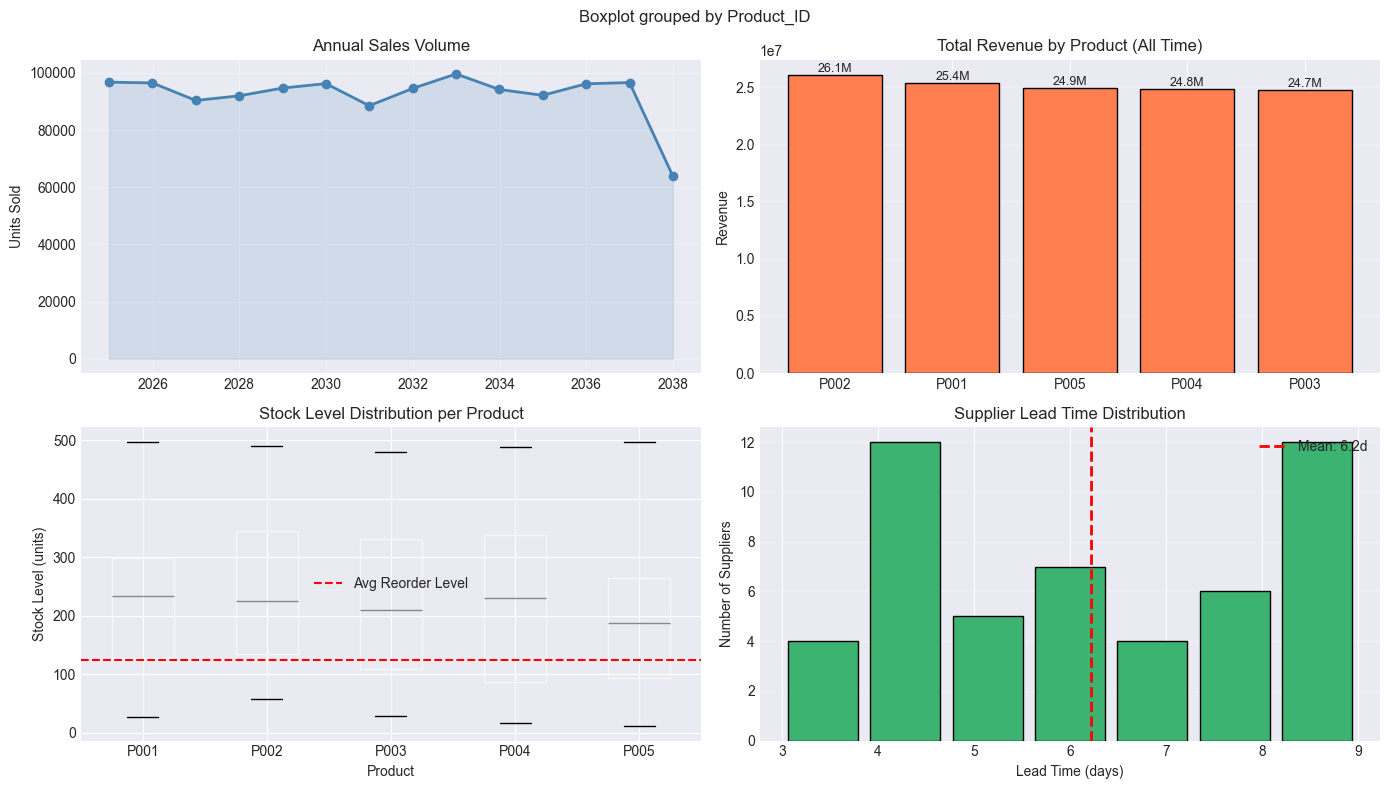

In [4]:
# ── EDA: 4-panel overview ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ABC Supermarket — Dataset Overview', fontsize=14, fontweight='bold')

# 1. Monthly sales trend (165 months of data — line chart is correct here)
monthly = sales_df.set_index('Sale_Date').resample('YE')['Quantity_Sold'].sum()
axes[0,0].plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
axes[0,0].set_title('Annual Sales Volume')
axes[0,0].set_ylabel('Units Sold')
axes[0,0].grid(True, alpha=0.3)

# 2. Revenue by product (all time — meaningful since 5 products)
rev = sales_df.groupby('Product_ID')['Revenue'].sum().sort_values(ascending=False)
axes[0,1].bar(rev.index, rev.values, color='coral', edgecolor='black')
axes[0,1].set_title('Total Revenue by Product (All Time)')
axes[0,1].set_ylabel('Revenue')
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(rev.values):
    axes[0,1].text(i, v + rev.max()*0.01, f'{v/1e6:.1f}M', ha='center', fontsize=9)

# 3. Stock level distribution per product — box plot shows spread across 40 stores
inventory_df.boxplot(column='Stock_Level', by='Product_ID', ax=axes[1,0])
axes[1,0].axhline(y=inventory_df['Reorder_Level'].mean(), color='red',
                linestyle='--', linewidth=1.5, label='Avg Reorder Level')
axes[1,0].set_title('Stock Level Distribution per Product\n(across all stores)')
axes[1,0].set_xlabel('Product')
axes[1,0].set_ylabel('Stock Level (units)')
axes[1,0].legend()
plt.sca(axes[1,0]); plt.title('Stock Level Distribution per Product')

# 4. Supplier lead time distribution
axes[1,1].hist(suppliers_df['Lead_Time (days)'], bins=7,
            color='mediumseagreen', edgecolor='black', rwidth=0.85)
axes[1,1].axvline(x=suppliers_df['Lead_Time (days)'].mean(), color='red',
                linestyle='--', linewidth=2, label=f"Mean: {suppliers_df['Lead_Time (days)'].mean():.1f}d")
axes[1,1].set_title('Supplier Lead Time Distribution')
axes[1,1].set_xlabel('Lead Time (days)')
axes[1,1].set_ylabel('Number of Suppliers')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 2. SQL Tasks — Inventory Analytics & Reporting

All four tables are loaded into an in-memory SQLite database.
Each task shows the **MySQL** query first, then executes it live in SQLite.

> **Note on thresholds:** The CASE thresholds for Fast/Moderate/Slow are set based on
> the actual distribution of 3-month product sales (mean ± 1 std), not arbitrary fixed values.
> This ensures the classification is meaningful for this dataset.


In [ ]:
# Set up SQL database
conn = sqlite3.connect(':memory:')
sales_df.to_sql('sales',           conn, index=False, if_exists='replace')
inventory_df.to_sql('inventory',   conn, index=False, if_exists='replace')
suppliers_df.to_sql('suppliers',   conn, index=False, if_exists='replace')
purchase_orders_df.to_sql('purchase_orders', conn, index=False, if_exists='replace')

# Calculate data-driven thresholds for product movement classification
latest_date     = sales_df['Sale_Date'].max()
three_months_ago = latest_date - pd.DateOffset(months=3)
recent_totals   = (sales_df[sales_df['Sale_Date'] >= three_months_ago]
                .groupby('Product_ID')['Quantity_Sold'].sum())

thresh_fast = int(recent_totals.mean() + recent_totals.std() * 0.25)
thresh_slow = int(recent_totals.mean() - recent_totals.std() * 0.25)

print(f"3-month product sales range: {recent_totals.min():,} - {recent_totals.max():,}")
print(f"Mean: {recent_totals.mean():,.0f}  |  Std: {recent_totals.std():,.0f}")
print(f"\nData-driven thresholds:")
print(f"  Fast Moving : > {thresh_fast:,} units")
print(f"  Moderate    : {thresh_slow:,} - {thresh_fast:,} units")
print(f"  Slow Moving : < {thresh_slow:,} units")


3-month product sales range: 3,759 - 6,011
Mean: 4,615  |  Std: 849

Data-driven thresholds:
  Fast Moving : > 4,826 units
  Moderate    : 4,402 - 4,826 units
  Slow Moving : < 4,402 units


---
### Task 2.1 — Fast-Moving vs Slow-Moving Products

**Business question:** Which products have the highest and lowest sales in the past 3 months?


In [ ]:
# MySQL Query (production syntax — thresholds set from data distribution)
mysql_q1 = '''
SELECT
    Product_ID,
    SUM(Quantity_Sold) AS Total_Sales,
    SUM(Revenue)       AS Total_Revenue,
    COUNT(Sale_ID)     AS Transactions,
    CASE
        WHEN SUM(Quantity_Sold) > {thresh_fast}  THEN 'Fast Moving'
        WHEN SUM(Quantity_Sold) >= {thresh_slow} THEN 'Moderate'
        ELSE                                          'Slow Moving'
    END AS Sales_Category
FROM sales
WHERE Sale_Date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
GROUP BY Product_ID
ORDER BY Total_Sales DESC;
'''
print("MySQL Query — Fast vs Slow Moving Products:")
print(mysql_q1)


MySQL Query — Fast vs Slow Moving Products:

SELECT
    Product_ID,
    SUM(Quantity_Sold) AS Total_Sales,
    SUM(Revenue)       AS Total_Revenue,
    COUNT(Sale_ID)     AS Transactions,
    CASE
        WHEN SUM(Quantity_Sold) > {thresh_fast}  THEN 'Fast Moving'
        WHEN SUM(Quantity_Sold) >= {thresh_slow} THEN 'Moderate'
        ELSE                                              'Slow Moving'
    END AS Sales_Category
FROM sales
WHERE Sale_Date >= DATE_SUB(CURDATE(), INTERVAL 3 MONTH)
GROUP BY Product_ID
ORDER BY Total_Sales DESC;



In [7]:
# Execute in SQLite
q1 = f'''
SELECT
    Product_ID,
    SUM(Quantity_Sold)     AS Total_Sales,
    ROUND(SUM(Revenue),2)  AS Total_Revenue,
    COUNT(Sale_ID)         AS Transactions,
    CASE
        WHEN SUM(Quantity_Sold) > {thresh_fast}  THEN 'Fast Moving'
        WHEN SUM(Quantity_Sold) >= {thresh_slow} THEN 'Moderate'
        ELSE                                         'Slow Moving'
    END AS Sales_Category
FROM sales
WHERE Sale_Date >= date('{latest_date.date()}', '-3 months')
GROUP BY Product_ID
ORDER BY Total_Sales DESC
'''

product_movement = pd.read_sql_query(q1, conn)

print("=" * 62)
print("  PRODUCT MOVEMENT — Last 3 Months")
print("=" * 62)
display(product_movement)
print("\nCategory summary:")
print(product_movement.groupby('Sales_Category')[['Product_ID']].count()
      .rename(columns={'Product_ID':'Count'}))


  PRODUCT MOVEMENT — Last 3 Months


,Product_ID,Total_Sales,Total_Revenue,Transactions,Sales_Category
0,P004,6011,541901.0,21,Fast Moving
1,P003,4650,526359.0,19,Moderate
2,P002,4454,436789.0,18,Moderate
3,P005,4200,447391.0,17,Slow Moving
4,P001,3759,375331.0,18,Slow Moving



Category summary:
                Count
Sales_Category       
Fast Moving         1
Moderate            2
Slow Moving         2


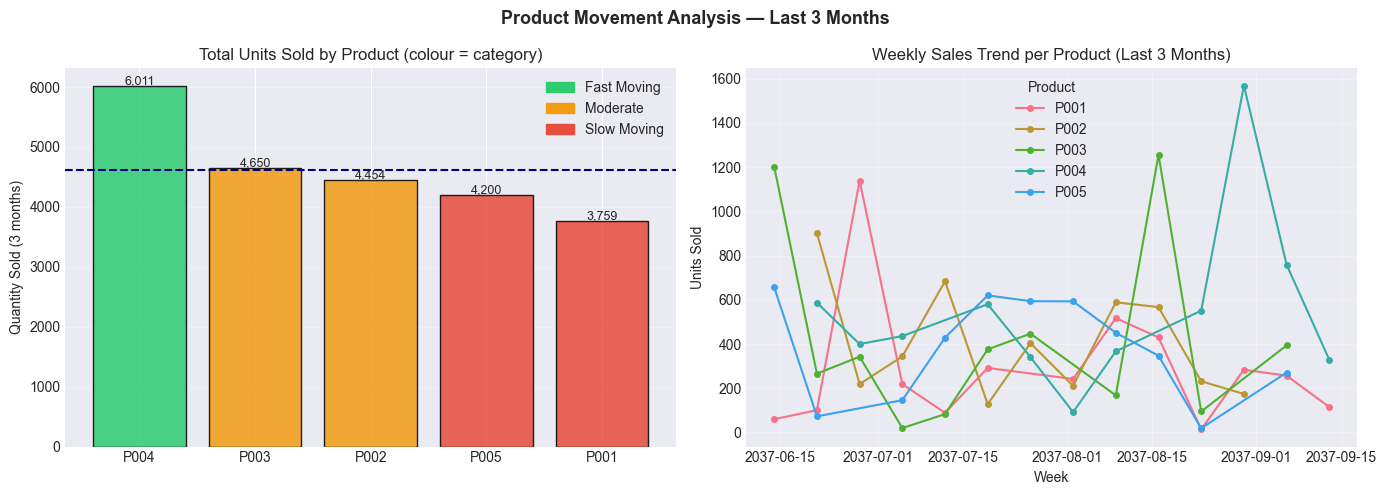

In [8]:
# Visualisation — Task 2.1
cat_colors = {'Fast Moving': '#2ecc71', 'Moderate': '#f39c12', 'Slow Moving': '#e74c3c'}
bar_c = [cat_colors.get(c, 'grey') for c in product_movement['Sales_Category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Product Movement Analysis — Last 3 Months', fontsize=13, fontweight='bold')

# Left: total units sold with category colour
bars = axes[0].bar(product_movement['Product_ID'], product_movement['Total_Sales'],
                   color=bar_c, edgecolor='black', alpha=0.85)
axes[0].axhline(y=product_movement['Total_Sales'].mean(), color='navy',
                linestyle='--', linewidth=1.5, label='Average')
axes[0].set_title('Total Units Sold by Product (colour = category)')
axes[0].set_ylabel('Quantity Sold (3 months)')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, product_movement['Total_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9)
handles = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
axes[0].legend(handles=handles)

# Right: weekly trend per product (shows HOW sales moved, not just totals)
recent_weekly = (sales_df[sales_df['Sale_Date'] >= three_months_ago]
                 .groupby(['Product_ID', pd.Grouper(key='Sale_Date', freq='W')])
                 ['Quantity_Sold'].sum().reset_index())

for pid in recent_weekly['Product_ID'].unique():
    subset = recent_weekly[recent_weekly['Product_ID'] == pid]
    axes[1].plot(subset['Sale_Date'], subset['Quantity_Sold'],
                 marker='o', markersize=4, linewidth=1.5, label=pid)

axes[1].set_title('Weekly Sales Trend per Product (Last 3 Months)')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Units Sold')
axes[1].legend(title='Product')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
### Task 2.2 — Products Below Reorder Level

**Business question:** Which products need restocking right now — and how urgently?

- **Critical**: stock below 50% of reorder threshold — immediate action needed
- **Low Stock**: stock below reorder level — order soon


In [9]:
# MySQL Query
mysql_q2 = '''
SELECT
    Product_ID,
    Store_ID,
    Warehouse_ID,
    Stock_Level,
    Reorder_Level,
    (Reorder_Level - Stock_Level) AS Reorder_Quantity,
    CASE
        WHEN Stock_Level < Reorder_Level * 0.5 THEN 'Critical'
        ELSE                                        'Low Stock'
    END AS Stock_Status
FROM inventory
WHERE Stock_Level < Reorder_Level
ORDER BY Reorder_Quantity DESC;
'''
print("MySQL Query — Products Below Reorder Level:")
print(mysql_q2)


MySQL Query — Products Below Reorder Level:

SELECT
    Product_ID,
    Store_ID,
    Warehouse_ID,
    Stock_Level,
    Reorder_Level,
    (Reorder_Level - Stock_Level) AS Reorder_Quantity,
    CASE
        WHEN Stock_Level < Reorder_Level * 0.5 THEN 'Critical'
        ELSE                                        'Low Stock'
    END AS Stock_Status
FROM inventory
WHERE Stock_Level < Reorder_Level
ORDER BY Reorder_Quantity DESC;



In [10]:
# Execute in SQLite
q2 = '''
SELECT
    Product_ID, Store_ID, Warehouse_ID,
    Stock_Level, Reorder_Level,
    (Reorder_Level - Stock_Level) AS Reorder_Quantity,
    CASE
        WHEN Stock_Level < Reorder_Level * 0.5 THEN 'Critical'
        ELSE                                        'Low Stock'
    END AS Stock_Status
FROM inventory
WHERE Stock_Level < Reorder_Level
ORDER BY Reorder_Quantity DESC
'''
restock_report = pd.read_sql_query(q2, conn)
pct_below = len(restock_report) / len(inventory_df) * 100

print("=" * 60)
print("  RESTOCK ALERT REPORT")
print("=" * 60)
print(f"  Total inventory records  : {len(inventory_df)}")
print(f"  Below reorder level      : {len(restock_report)} ({pct_below:.1f}%)")
print(f"  Critical                 : {(restock_report['Stock_Status']=='Critical').sum()}")
print(f"  Low Stock                : {(restock_report['Stock_Status']=='Low Stock').sum()}")
print()
display(restock_report.head(15))


  RESTOCK ALERT REPORT
  Total inventory records  : 200
  Below reorder level      : 53 (26.5%)
  Critical                 : 25
  Low Stock                : 28



,Product_ID,Store_ID,Warehouse_ID,Stock_Level,Reorder_Level,Reorder_Quantity,Stock_Status
0,P005,S104,W003,11,194,183,Critical
1,P004,S103,W003,24,178,154,Critical
2,P004,S103,W002,18,148,130,Critical
3,P004,S102,W003,41,165,124,Critical
4,P004,S101,W001,43,165,122,Critical
5,P001,S101,W003,72,192,120,Critical
6,P003,S102,W003,49,168,119,Critical
7,P003,S101,W002,52,166,114,Critical
8,P005,S104,W003,52,162,110,Critical
9,P004,S101,W002,87,190,103,Critical


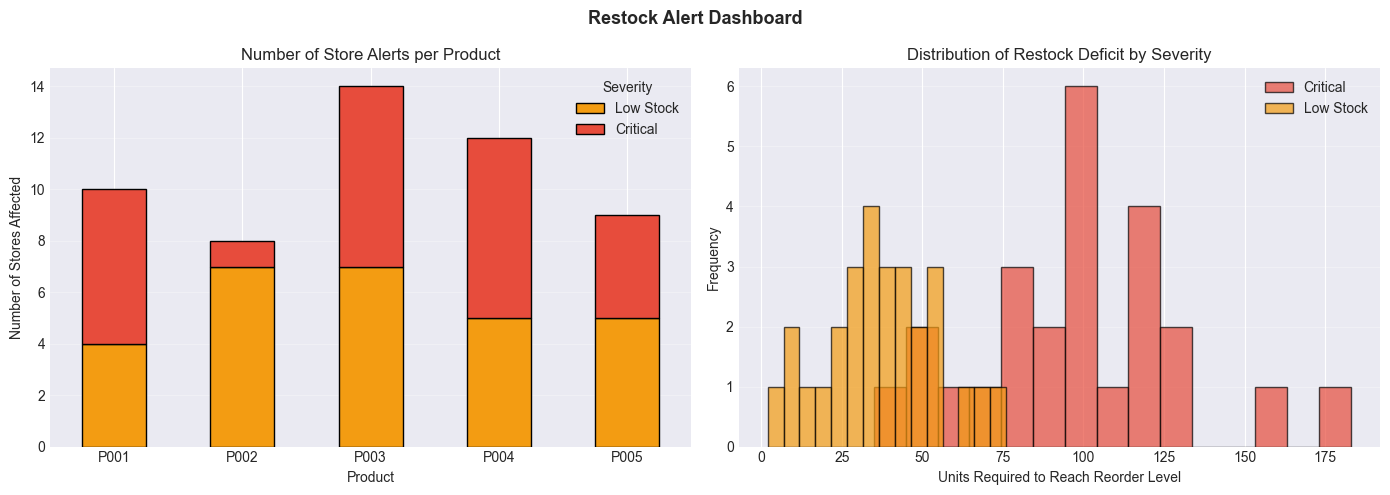

In [11]:
# Visualisation — Task 2.2
status_colors = {'Critical': '#e74c3c', 'Low Stock': '#f39c12'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Restock Alert Dashboard', fontsize=13, fontweight='bold')

# Left: count of alerts per product, stacked by severity
alert_counts = (restock_report.groupby(['Product_ID','Stock_Status'])
                .size().unstack(fill_value=0))
# Ensure both columns exist
for col in ['Critical','Low Stock']:
    if col not in alert_counts.columns:
        alert_counts[col] = 0

alert_counts[['Low Stock','Critical']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#f39c12','#e74c3c'], edgecolor='black')
axes[0].set_title('Number of Store Alerts per Product')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Number of Stores Affected')
axes[0].legend(title='Severity')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Right: distribution of reorder quantity (deficit) by severity
for status, grp in restock_report.groupby('Stock_Status'):
    axes[1].hist(grp['Reorder_Quantity'], bins=15, alpha=0.7,
                 color=status_colors[status], label=status, edgecolor='black')
axes[1].set_title('Distribution of Restock Deficit by Severity')
axes[1].set_xlabel('Units Required to Reach Reorder Level')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---
### Task 2.3 — Supplier Lead Time Analysis

**Business question:** Which suppliers have high lead times, and what faster alternatives exist for the same product?


In [12]:
# MySQL Query
mysql_q3 = '''
-- Part A: Rank and classify suppliers
SELECT
    Supplier_ID, Supplier_Name,
    AVG(`Lead_Time (days)`)  AS Avg_Lead_Time,
    COUNT(Product_ID)        AS Products_Supplied,
    CASE
        WHEN AVG(`Lead_Time (days)`) > 7 THEN 'High Risk'
        ELSE                                  'Efficient'
    END AS Supplier_Category
FROM suppliers
GROUP BY Supplier_ID, Supplier_Name
ORDER BY Avg_Lead_Time DESC;

-- Part B: Suggest faster alternatives for same product
SELECT
    s1.Product_ID,
    s1.Supplier_ID           AS Current_Supplier,
    s1.`Lead_Time (days)`    AS Current_LT,
    s2.Supplier_ID           AS Faster_Alternative,
    s2.`Lead_Time (days)`    AS Alternative_LT,
    (s1.`Lead_Time (days)` - s2.`Lead_Time (days)`) AS Days_Saved
FROM suppliers s1
JOIN suppliers s2
    ON  s1.Product_ID = s2.Product_ID
    AND s2.`Lead_Time (days)` < s1.`Lead_Time (days)`
WHERE s1.`Lead_Time (days)` > (SELECT AVG(`Lead_Time (days)`) FROM suppliers)
ORDER BY Days_Saved DESC;
'''
print("MySQL Query — Supplier Lead Time Analysis:")
print(mysql_q3)


MySQL Query — Supplier Lead Time Analysis:

-- Part A: Rank and classify suppliers
SELECT
    Supplier_ID, Supplier_Name,
    AVG(`Lead_Time (days)`)  AS Avg_Lead_Time,
    COUNT(Product_ID)        AS Products_Supplied,
    CASE
        WHEN AVG(`Lead_Time (days)`) > 7 THEN 'High Risk'
        ELSE                                  'Efficient'
    END AS Supplier_Category
FROM suppliers
GROUP BY Supplier_ID, Supplier_Name
ORDER BY Avg_Lead_Time DESC;

-- Part B: Suggest faster alternatives for same product
SELECT
    s1.Product_ID,
    s1.Supplier_ID           AS Current_Supplier,
    s1.`Lead_Time (days)`    AS Current_LT,
    s2.Supplier_ID           AS Faster_Alternative,
    s2.`Lead_Time (days)`    AS Alternative_LT,
    (s1.`Lead_Time (days)` - s2.`Lead_Time (days)`) AS Days_Saved
FROM suppliers s1
JOIN suppliers s2
    ON  s1.Product_ID = s2.Product_ID
    AND s2.`Lead_Time (days)` < s1.`Lead_Time (days)`
WHERE s1.`Lead_Time (days)` > (SELECT AVG(`Lead_Time (days)`) FROM supplier

In [13]:
# Execute Part A
q3a = '''
SELECT Supplier_ID, Supplier_Name,
    ROUND(AVG("Lead_Time (days)"), 2) AS Avg_Lead_Time,
    COUNT(Product_ID)                 AS Products_Supplied,
    CASE
        WHEN AVG("Lead_Time (days)") > 7 THEN 'High Risk'
        ELSE                                  'Efficient'
    END AS Supplier_Category
FROM suppliers
GROUP BY Supplier_ID, Supplier_Name
ORDER BY Avg_Lead_Time DESC
'''
supplier_ranking = pd.read_sql_query(q3a, conn)

print("=" * 58)
print("  SUPPLIER RANKING BY LEAD TIME")
print("=" * 58)
print(f"  High Risk (> 7 days) : {(supplier_ranking['Supplier_Category']=='High Risk').sum()}")
print(f"  Efficient            : {(supplier_ranking['Supplier_Category']=='Efficient').sum()}")
print()
display(supplier_ranking.head(12))


  SUPPLIER RANKING BY LEAD TIME
  High Risk (> 7 days) : 18
  Efficient            : 32



,Supplier_ID,Supplier_Name,Avg_Lead_Time,Products_Supplied,Supplier_Category
0,SUP001,Murray-Ramirez,9.0,1,High Risk
1,SUP002,"Thomas, Meyer and Campbell",9.0,1,High Risk
2,SUP007,"Meyers, Miller and Young",9.0,1,High Risk
3,SUP010,Wright PLC,9.0,1,High Risk
4,SUP029,"Duncan, Davidson and Martin",9.0,1,High Risk
5,SUP033,Murphy-Wise,9.0,1,High Risk
6,SUP034,"James, Mullen and Cooper",9.0,1,High Risk
7,SUP035,Smith PLC,9.0,1,High Risk
8,SUP036,"Powers, Olson and Sanchez",9.0,1,High Risk
9,SUP043,Fox Group,9.0,1,High Risk


In [14]:
# Execute Part B — faster alternatives
q3b = '''
SELECT
    s1.Product_ID,
    s1.Supplier_ID          AS Slow_Supplier,
    s1."Lead_Time (days)"   AS Slow_LT,
    s2.Supplier_ID          AS Faster_Alternative,
    s2."Lead_Time (days)"   AS Faster_LT,
    (s1."Lead_Time (days)" - s2."Lead_Time (days)") AS Days_Saved
FROM suppliers s1
JOIN suppliers s2
    ON  s1.Product_ID = s2.Product_ID
    AND s2."Lead_Time (days)" < s1."Lead_Time (days)"
WHERE s1."Lead_Time (days)" > (SELECT AVG(s."Lead_Time (days)") FROM suppliers s)
ORDER BY Days_Saved DESC
LIMIT 15
'''
alternatives = pd.read_sql_query(q3b, conn)
print("=" * 60)
print("  FASTER SUPPLIER ALTERNATIVES (same product)")
print("=" * 60)
display(alternatives.head(10))


  FASTER SUPPLIER ALTERNATIVES (same product)


,Product_ID,Slow_Supplier,Slow_LT,Faster_Alternative,Faster_LT,Days_Saved
0,P002,SUP001,9,SUP028,3,6
1,P005,SUP002,9,SUP032,3,6
2,P005,SUP002,9,SUP039,3,6
3,P002,SUP007,9,SUP028,3,6
4,P003,SUP010,9,SUP041,3,6
5,P005,SUP029,9,SUP032,3,6
6,P005,SUP029,9,SUP039,3,6
7,P002,SUP043,9,SUP028,3,6
8,P002,SUP046,9,SUP028,3,6
9,P005,SUP049,9,SUP032,3,6


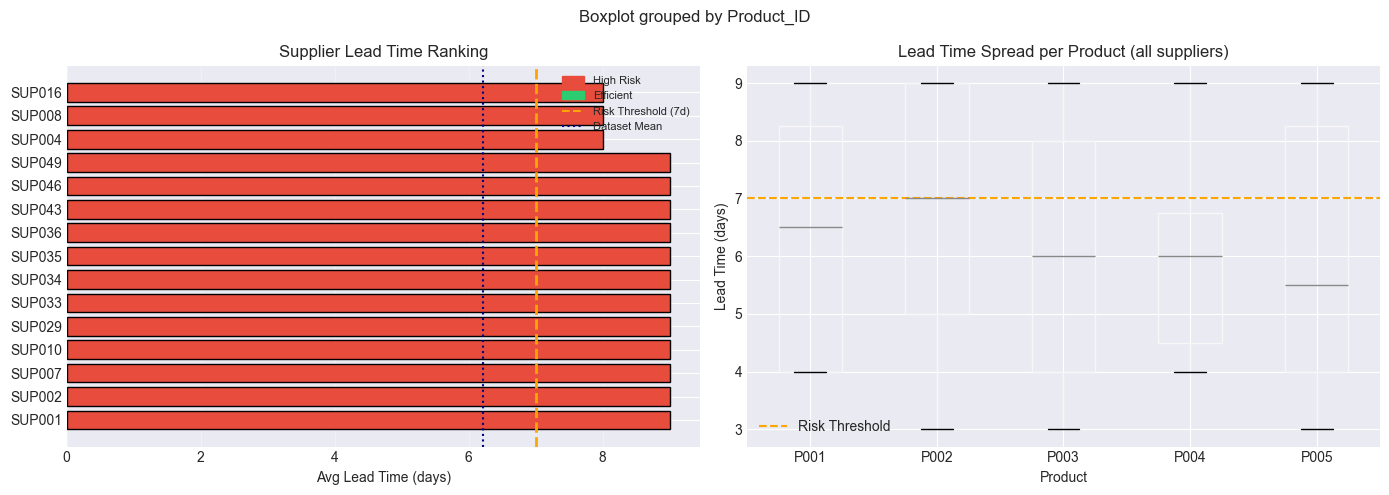

In [15]:
# Visualisation — Task 2.3
cat_col = {'High Risk': '#e74c3c', 'Efficient': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supplier Lead Time Analysis', fontsize=13, fontweight='bold')

# Left: ranked bar chart of all suppliers
top15  = supplier_ranking.head(15)
colors = [cat_col[c] for c in top15['Supplier_Category']]
axes[0].barh(top15['Supplier_ID'], top15['Avg_Lead_Time'],
             color=colors, edgecolor='black')
axes[0].axvline(x=7, color='orange', linestyle='--', linewidth=2, label='Risk Threshold (7 days)')
axes[0].axvline(x=suppliers_df['Lead_Time (days)'].mean(), color='navy',
                linestyle=':', linewidth=1.5, label=f"Dataset Mean ({suppliers_df['Lead_Time (days)'].mean():.1f}d)")
axes[0].set_xlabel('Avg Lead Time (days)')
axes[0].set_title('Supplier Lead Time Ranking')
handles  = [mpatches.Patch(color=c, label=l) for l, c in cat_col.items()]
handles += [plt.Line2D([0],[0], color='orange', linestyle='--', label='Risk Threshold (7d)'),
            plt.Line2D([0],[0], color='navy',   linestyle=':',  label='Dataset Mean')]
axes[0].legend(handles=handles, fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

# Right: lead time distribution per product (box plot — shows spread of suppliers per product)
suppliers_df.boxplot(column='Lead_Time (days)', by='Product_ID', ax=axes[1])
axes[1].axhline(y=7, color='orange', linestyle='--', linewidth=1.5, label='Risk Threshold')
axes[1].set_title('Lead Time Range per Product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Lead Time (days)')
axes[1].legend()
plt.sca(axes[1]); plt.title('Lead Time Spread per Product (all suppliers)')

plt.tight_layout()
plt.show()


## 3. Python Tasks — Forecasting & Optimisation

### Task 3.1 — Demand Forecasting (Scikit-Learn)

**Approach:** Engineer time-series features from the date column and train a
**Linear Regression** model (Scikit-Learn) on historical daily sales.
Moving averages provide trend context. The model predicts demand for each day of the next month.


In [16]:
# Aggregate to daily total sales across all products
daily_sales = (sales_df.groupby('Sale_Date')
               .agg(Quantity_Sold=('Quantity_Sold','sum'),
                    Revenue=('Revenue','sum'))
               .reset_index()
               .sort_values('Sale_Date'))

# Each row is already one unique date (5000 unique dates in 5000 rows)
# Feature engineering
daily_sales['Day_Number']  = range(len(daily_sales))
daily_sales['Day_of_Week'] = daily_sales['Sale_Date'].dt.dayofweek
daily_sales['Month']       = daily_sales['Sale_Date'].dt.month

# Moving averages for trend context
daily_sales['MA_7']  = daily_sales['Quantity_Sold'].rolling(7,  min_periods=1).mean()
daily_sales['MA_30'] = daily_sales['Quantity_Sold'].rolling(30, min_periods=1).mean()

print(f"Time-series prepared:")
print(f"  Date range       : {daily_sales['Sale_Date'].min().date()} -> {daily_sales['Sale_Date'].max().date()}")
print(f"  Total days       : {len(daily_sales):,}")
print(f"  Avg daily demand : {daily_sales['Quantity_Sold'].mean():.1f} units")
print(f"  Min daily demand : {daily_sales['Quantity_Sold'].min():.0f} units")
print(f"  Max daily demand : {daily_sales['Quantity_Sold'].max():.0f} units")


Time-series prepared:
  Date range       : 2024-01-01 -> 2037-09-08
  Total days       : 5,000
  Avg daily demand : 258.4 units
  Min daily demand : 10 units
  Max daily demand : 499 units


In [17]:
# Train Linear Regression (Scikit-Learn)
features = ['Day_Number', 'Day_of_Week', 'Month']
X_train  = daily_sales[features].values
y_train  = daily_sales['Quantity_Sold'].values

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
r2   = model.score(X_train, y_train)
mae  = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("Model: Linear Regression (Scikit-Learn)")
print(f"Features : {features}")
print()
print(f"  R² Score : {r2:.4f}")
print(f"  MAE      : {mae:.1f} units/day")
print(f"  RMSE     : {rmse:.1f} units/day")
print()
print("Feature coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:<15}: {coef:+.4f}")
print(f"  {'Intercept':<15}: {model.intercept_:+.4f}")


Model: Linear Regression (Scikit-Learn)
Features : ['Day_Number', 'Day_of_Week', 'Month']

  R² Score : 0.0002
  MAE      : 123.5 units/day
  RMSE     : 142.2 units/day

Feature coefficients:
  Day_Number     : +0.0004
  Day_of_Week    : +0.7956
  Month          : -0.3243
  Intercept      : +257.0844


In [18]:
# Forecast next 30 days
last_day     = daily_sales['Day_Number'].max()
future_dates = pd.date_range(
    daily_sales['Sale_Date'].max() + pd.Timedelta(days=1), periods=30, freq='D')

X_future = pd.DataFrame({
    'Day_Number' : range(last_day+1, last_day+31),
    'Day_of_Week': [d.dayofweek for d in future_dates],
    'Month'      : [d.month     for d in future_dates]
})
preds = np.maximum(model.predict(X_future.values), 0)

forecast_df = pd.DataFrame({
    'Date'          : future_dates,
    'Predicted_Qty' : preds.round(0).astype(int)
})

print("=" * 52)
print("  DEMAND FORECAST — NEXT 30 DAYS (All Products)")
print("=" * 52)
print(f"  Total predicted demand : {preds.sum():,.0f} units")
print(f"  Average daily demand   : {preds.mean():.1f} units/day")
print(f"  Peak day               : {future_dates[preds.argmax()].date()} ({preds.max():.0f} units)")
print()
display(forecast_df.head(10))


  DEMAND FORECAST — NEXT 30 DAYS (All Products)
  Total predicted demand : 7,756 units
  Average daily demand   : 258.5 units/day
  Peak day               : 2037-09-27 (261 units)



,Date,Predicted_Qty
0,2037-09-09,258
1,2037-09-10,259
2,2037-09-11,259
3,2037-09-12,260
4,2037-09-13,261
5,2037-09-14,256
6,2037-09-15,257
7,2037-09-16,258
8,2037-09-17,259
9,2037-09-18,259


In [19]:
# Per-product forecast
product_forecasts = []
for pid in sorted(sales_df['Product_ID'].unique()):
    ps = sales_df[sales_df['Product_ID']==pid].copy()
    daily = ps.groupby('Sale_Date')['Quantity_Sold'].sum().reset_index().sort_values('Sale_Date')
    daily['Day_Number']  = range(len(daily))
    daily['Day_of_Week'] = daily['Sale_Date'].dt.dayofweek
    daily['Month']       = daily['Sale_Date'].dt.month

    m = LinearRegression().fit(daily[features].values, daily['Quantity_Sold'].values)

    last_d = daily['Day_Number'].max()
    fut_d  = pd.date_range(daily['Sale_Date'].max() + pd.Timedelta(days=1), periods=30)
    Xf = pd.DataFrame({
        'Day_Number' : range(last_d+1, last_d+31),
        'Day_of_Week': [d.dayofweek for d in fut_d],
        'Month'      : [d.month     for d in fut_d]})
    fc = np.maximum(m.predict(Xf.values), 0).sum()

    product_forecasts.append({
        'Product_ID'       : pid,
        'Avg_Daily_Demand' : round(daily['Quantity_Sold'].mean(), 2),
        'Monthly_Forecast' : round(fc, 0),
        'Model_R2'         : round(m.score(daily[features].values,
                                           daily['Quantity_Sold'].values), 4)
    })

forecast_by_product = pd.DataFrame(product_forecasts).sort_values('Monthly_Forecast', ascending=False)

print("=" * 58)
print("  PRODUCT-LEVEL FORECAST — NEXT 30 DAYS")
print("=" * 58)
print(forecast_by_product.to_string(index=False))


  PRODUCT-LEVEL FORECAST — NEXT 30 DAYS
Product_ID  Avg_Daily_Demand  Monthly_Forecast  Model_R2
      P002            264.34            8248.0    0.0019
      P004            262.57            8002.0    0.0013
      P005            261.86            7866.0    0.0012
      P003            254.38            7483.0    0.0060
      P001            249.33            7221.0    0.0013


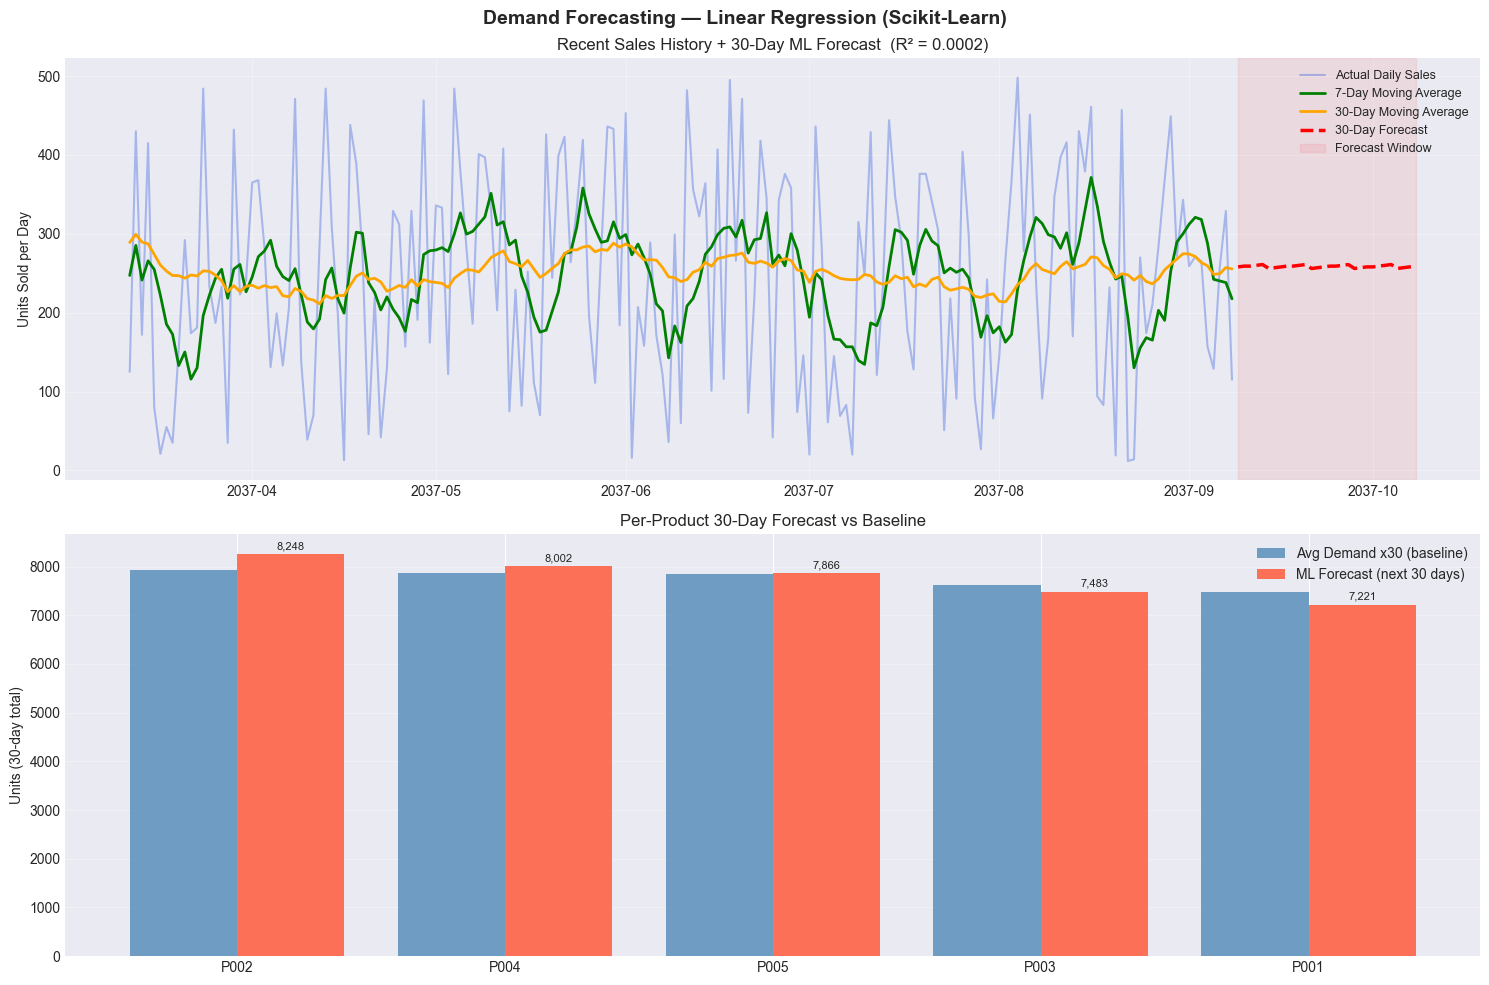

In [ ]:
# Visualisation — Task 3.1
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Demand Forecasting — Linear Regression (Scikit-Learn)', fontsize=14, fontweight='bold')

# Top: last 180 days of history + 7-day MA + 30-day forecast
recent_history = daily_sales[daily_sales['Sale_Date'] >= daily_sales['Sale_Date'].max() - pd.Timedelta(days=180)]
axes[0].plot(recent_history['Sale_Date'], recent_history['Quantity_Sold'],
            alpha=0.4, color='royalblue', label='Actual Daily Sales')
axes[0].plot(recent_history['Sale_Date'], recent_history['MA_7'],
            color='green', linewidth=2, label='7-Day Moving Average')
axes[0].plot(recent_history['Sale_Date'], recent_history['MA_30'],
            color='orange', linewidth=2, label='30-Day Moving Average')
axes[0].plot(forecast_df['Date'], forecast_df['Predicted_Qty'],
            color='red', linewidth=2.5, linestyle='--', label='30-Day Forecast')
axes[0].axvspan(forecast_df['Date'].min(), forecast_df['Date'].max(),
                alpha=0.07, color='red', label='Forecast Window')
axes[0].set_ylabel('Units Sold per Day')
axes[0].set_title(f'Recent Sales History + 30-Day ML Forecast  (R² = {r2:.4f})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: per-product forecast vs average baseline
x = np.arange(len(forecast_by_product)); w = 0.4
axes[1].bar(x - w/2, forecast_by_product['Avg_Daily_Demand'] * 30, w,
            label='Avg Demand x30 (baseline)', color='steelblue', alpha=0.75)
axes[1].bar(x + w/2, forecast_by_product['Monthly_Forecast'], w,
            label='ML Forecast (next 30 days)', color='tomato', alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(forecast_by_product['Product_ID'])
axes[1].set_ylabel('Units (30-day total)')
axes[1].set_title('Per-Product 30-Day Forecast vs Baseline')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, row in forecast_by_product.reset_index(drop=True).iterrows():
    axes[1].text(i + w/2, row['Monthly_Forecast'] + 100,
                f"{row['Monthly_Forecast']:,.0f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()


---
### Task 3.2 — Reorder Point Calculation

**Formula:**
```
Avg Daily Demand  =  Total Quantity Sold ÷ 90  (last 90 days)
Reorder Point     =  Avg Daily Demand × Lead Time
Safety Stock      =  Reorder Point × 10%
Final Reorder Pt  =  Reorder Point + Safety Stock
```


In [21]:
# Last 90 days demand per product
latest  = sales_df['Sale_Date'].max()
last90  = sales_df[sales_df['Sale_Date'] >= latest - pd.Timedelta(days=90)]

demand_90 = (last90.groupby('Product_ID')['Quantity_Sold']
             .sum().reset_index()
             .rename(columns={'Quantity_Sold':'Total_90d_Qty'}))
demand_90['Avg_Daily_Demand'] = (demand_90['Total_90d_Qty'] / 90).round(2)

# Average lead time per product
avg_lt = (suppliers_df.groupby('Product_ID')['Lead_Time (days)']
          .mean().reset_index()
          .rename(columns={'Lead_Time (days)':'Avg_Lead_Time'}))

# Apply formula
reorder_df = demand_90.merge(avg_lt, on='Product_ID', how='left')
reorder_df['Reorder_Point'] = (reorder_df['Avg_Daily_Demand'] * reorder_df['Avg_Lead_Time']).round(0)
reorder_df['Safety_Stock']  = (reorder_df['Reorder_Point'] * 0.10).round(0)
reorder_df['Final_ROP']     = (reorder_df['Reorder_Point'] + reorder_df['Safety_Stock']).round(0)

# Compare with current reorder levels
current_rl = (inventory_df.groupby('Product_ID')['Reorder_Level']
              .mean().reset_index()
              .rename(columns={'Reorder_Level':'Current_RL'}))
reorder_df = reorder_df.merge(current_rl, on='Product_ID', how='left')
reorder_df['Adjustment'] = (reorder_df['Final_ROP'] - reorder_df['Current_RL']).round(0)

print("=" * 72)
print("  OPTIMAL REORDER POINT  |  Formula: (Avg Daily Demand x Lead Time) + 10% SS")
print("=" * 72)
display(reorder_df[['Product_ID','Avg_Daily_Demand','Avg_Lead_Time',
                     'Reorder_Point','Safety_Stock','Final_ROP','Current_RL','Adjustment']])
print()
print("Positive Adjustment -> current RL too low  (stockout risk)")
print("Negative Adjustment -> current RL too high (overstock risk)")


  OPTIMAL REORDER POINT  |  Formula: (Avg Daily Demand x Lead Time) + 10% SS


,Product_ID,Avg_Daily_Demand,Avg_Lead_Time,Reorder_Point,Safety_Stock,Final_ROP,Current_RL,Adjustment
0,P001,41.77,6.250000,261.0,26.0,287.0,132.000000,155.0
1,P002,49.49,6.666667,330.0,33.0,363.0,123.025641,240.0
2,P003,51.67,6.000000,310.0,31.0,341.0,128.196078,213.0
3,P004,66.79,6.000000,401.0,40.0,441.0,120.444444,321.0
4,P005,42.94,6.000000,258.0,26.0,284.0,117.823529,166.0



Positive Adjustment -> current RL too low  (stockout risk)
Negative Adjustment -> current RL too high (overstock risk)


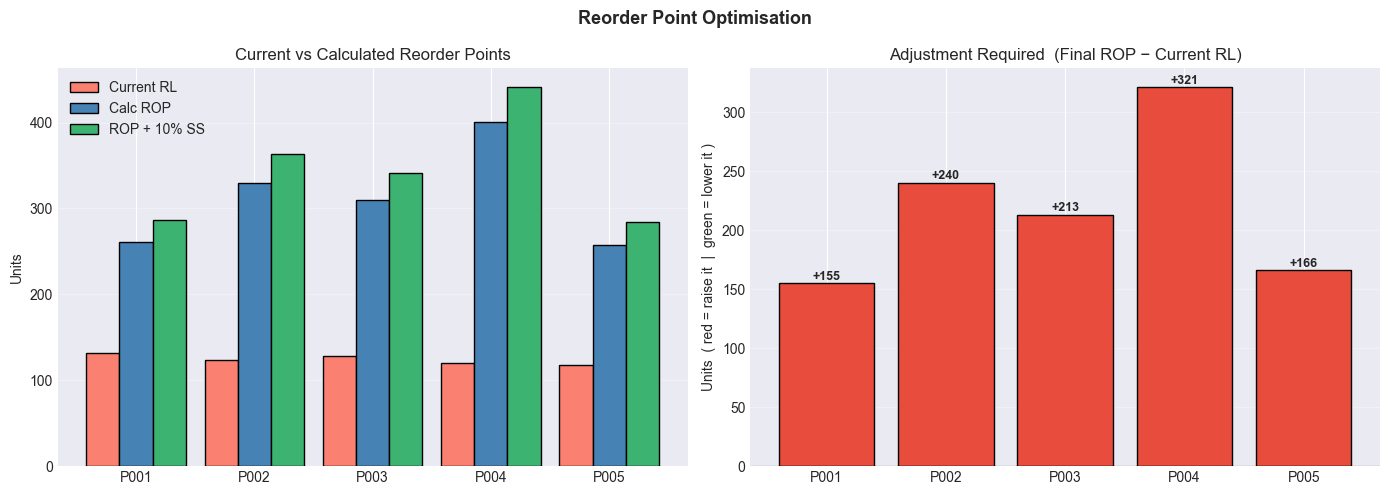

In [22]:
# Visualisation — Task 3.2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reorder Point Optimisation', fontsize=13, fontweight='bold')

x = np.arange(len(reorder_df)); w = 0.28

# Left: side-by-side comparison of 3 levels
axes[0].bar(x - w,   reorder_df['Current_RL'],    w, label='Current RL',    color='salmon',        edgecolor='black')
axes[0].bar(x,       reorder_df['Reorder_Point'],  w, label='Calc ROP',      color='steelblue',     edgecolor='black')
axes[0].bar(x + w,   reorder_df['Final_ROP'],      w, label='ROP + 10% SS',  color='mediumseagreen',edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(reorder_df['Product_ID'])
axes[0].set_ylabel('Units')
axes[0].set_title('Current vs Calculated Reorder Points')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: adjustment bar — how much each product needs to change
adj_colors = ['#e74c3c' if a > 0 else '#2ecc71' for a in reorder_df['Adjustment']]
axes[1].bar(reorder_df['Product_ID'], reorder_df['Adjustment'],
            color=adj_colors, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Adjustment Required  (Final ROP − Current RL)')
axes[1].set_ylabel('Units  ( red = raise it  |  green = lower it )')
axes[1].grid(axis='y', alpha=0.3)
for i, (_, row) in enumerate(reorder_df.iterrows()):
    axes[1].text(i, row['Adjustment'] + (3 if row['Adjustment'] >= 0 else -6),
                 f"{row['Adjustment']:+.0f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
### Task 3.3 — Supplier Performance Analysis (K-Means Clustering)

Suppliers are segmented using **K-Means** (Scikit-Learn) on two features:
- `Lead_Time (days)` — delivery speed
- `Order_Frequency` — encoded as orders per year (Weekly=52, Biweekly=26, Monthly=12)


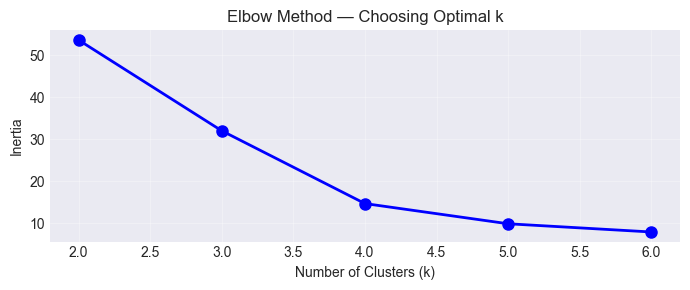

k=3 chosen: captures Fast / Standard / Slow supplier segments.


In [23]:
# Encode order frequency
freq_map = {'Weekly': 52, 'Biweekly': 26, 'Monthly': 12}
sup_c = suppliers_df.copy()
sup_c['Freq_Num'] = sup_c['Order_Frequency'].map(freq_map)

# Standardise features
X_clust  = sup_c[['Lead_Time (days)', 'Freq_Num']].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 7)]

plt.figure(figsize=(7, 3))
plt.plot(range(2,7), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing Optimal k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("k=3 chosen: captures Fast / Standard / Slow supplier segments.")


In [ ]:
# Fit K-Means k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sup_c['Cluster'] = kmeans.fit_predict(X_scaled)

# Label by average lead time
cluster_lt = sup_c.groupby('Cluster')['Lead_Time (days)'].mean()
label_map  = {cluster_lt.idxmin(): 'Fast (Low Lead Time)',
            cluster_lt.idxmax(): 'Slow (High Lead Time)'}
for k in cluster_lt.index:
    label_map.setdefault(k, 'Standard')
sup_c['Cluster_Label'] = sup_c['Cluster'].map(label_map)

# Summary
summary = (sup_c.groupby('Cluster_Label')
    .agg(Count=('Supplier_ID','count'),
        Avg_LT=('Lead_Time (days)','mean'),
        Min_LT=('Lead_Time (days)','min'),
        Max_LT=('Lead_Time (days)','max'),
        Avg_Freq_yr=('Freq_Num','mean'))
    .round(2))

print("=" * 58)
print("  SUPPLIER CLUSTER SUMMARY (K-Means, k=3)")
print("=" * 58)
display(summary)


  SUPPLIER CLUSTER SUMMARY (K-Means, k=3)


,Count,Avg_LT,Min_LT,Max_LT,Avg_Freq_yr
Cluster_Label,,,,,
Fast (Low Lead Time),20,4.60,3,6,19.00
Slow (High Lead Time),11,8.27,7,9,20.91
Standard,19,6.74,3,9,52.00


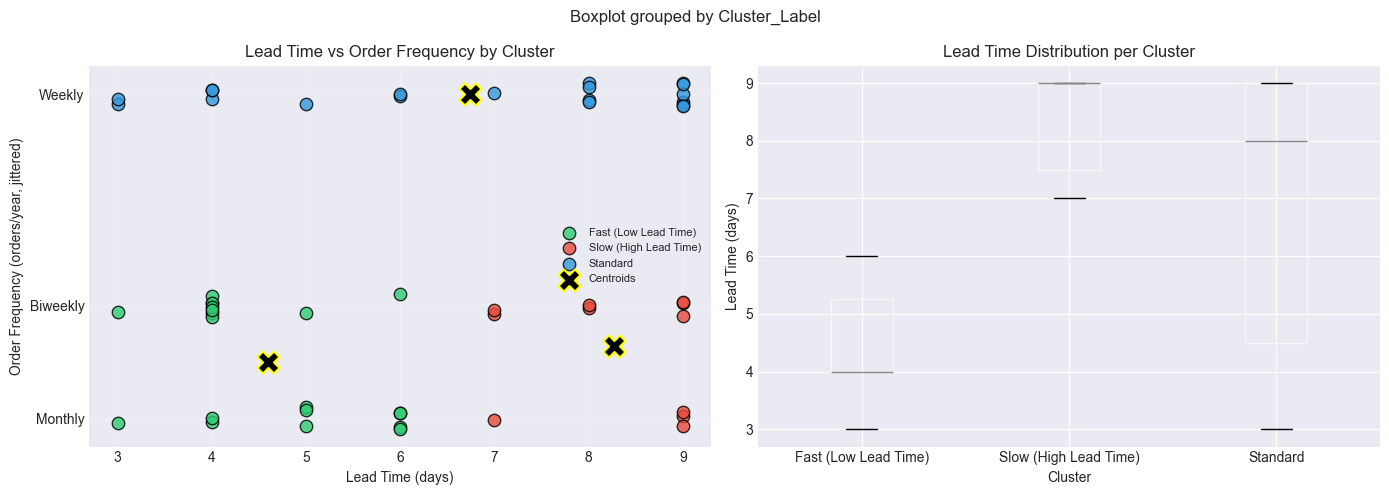


  SUPPLIER RECOMMENDATIONS

  [Fast (Low Lead Time)]  20 suppliers  |  avg LT: 4.6d
    -> Prioritise for urgent and high-volume orders

  [Standard]  19 suppliers  |  avg LT: 6.7d
    -> Maintain; monitor delivery consistency

  [Slow (High Lead Time)]  11 suppliers  |  avg LT: 8.3d
    -> Review contracts; switch to faster alternatives


In [25]:
# Visualisation — Task 3.3
palette = {'Fast (Low Lead Time)' : '#2ecc71',
           'Standard'             : '#3498db',
           'Slow (High Lead Time)': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supplier Performance Clustering — K-Means (k=3)', fontsize=13, fontweight='bold')

# Left: scatter with jitter on y-axis (only 3 frequency values, jitter aids visibility)
np.random.seed(42)
for lbl, grp in sup_c.groupby('Cluster_Label'):
    jitter = np.random.uniform(-1.5, 1.5, size=len(grp))
    axes[0].scatter(grp['Lead_Time (days)'],
                    grp['Freq_Num'] + jitter,
                    c=palette[lbl], label=lbl, s=80, alpha=0.8, edgecolors='black')

centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centers_orig[:,0], centers_orig[:,1],
                c='black', marker='X', s=250, zorder=5,
                label='Centroids', edgecolors='yellow', linewidths=1.5)
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('Order Frequency (orders/year, jittered)')
axes[0].set_yticks([12, 26, 52])
axes[0].set_yticklabels(['Monthly', 'Biweekly', 'Weekly'])
axes[0].set_title('Lead Time vs Order Frequency by Cluster')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: lead time distribution per cluster — box plot shows spread within each cluster
sup_c.boxplot(column='Lead_Time (days)', by='Cluster_Label', ax=axes[1])
axes[1].set_title('Lead Time Distribution per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Lead Time (days)')
plt.sca(axes[1]); plt.title('Lead Time Distribution per Cluster')

plt.tight_layout()
plt.show()

# Recommendations
print("\n" + "=" * 58)
print("  SUPPLIER RECOMMENDATIONS")
print("=" * 58)
recs = {'Fast (Low Lead Time)' : 'Prioritise for urgent and high-volume orders',
        'Standard'             : 'Maintain; monitor delivery consistency',
        'Slow (High Lead Time)': 'Review contracts; switch to faster alternatives'}
for lbl, action in recs.items():
    grp = sup_c[sup_c['Cluster_Label']==lbl]
    print(f"\n  [{lbl}]  {len(grp)} suppliers  |  avg LT: {grp['Lead_Time (days)'].mean():.1f}d")
    print(f"    -> {action}")


## 4. Data Warehousing Concepts

### Task 4.1 — Star Schema Design

A **star schema** places the business event in a central **Fact Table** joined to descriptive **Dimension Tables**.
This denormalised structure enables fast analytical queries — aggregations, slices, and drill-downs.

#### Fact Tables

| Table | Measures |
|---|---|
| **Fact_Sales** | Quantity_Sold, Revenue |
| **Fact_Inventory** | Stock_Level, Reorder_Quantity, Stockout_Days |

#### Dimension Tables

| Table | Key Columns | Purpose |
|---|---|---|
| **Dim_Product** | Product_Key, Product_ID, Category, Unit_Price | What was sold |
| **Dim_Store** | Store_Key, Store_ID, City, Region | Where it was sold |
| **Dim_Supplier** | Supplier_Key, Supplier_ID, Lead_Time, Cluster | Who supplies it |
| **Dim_Time** | Date_Key, Day, Month, Quarter, Year | When it happened |
| **Dim_Warehouse** | Warehouse_Key, Warehouse_ID, Location, Capacity | Where stock is held |

#### Relationships
- `Fact_Sales` links to `Dim_Product`, `Dim_Store`, `Dim_Time` via surrogate keys
- `Fact_Inventory` links to `Dim_Product`, `Dim_Warehouse`, `Dim_Time`
- Both fact tables can join `Dim_Supplier` through a product-supplier bridge table


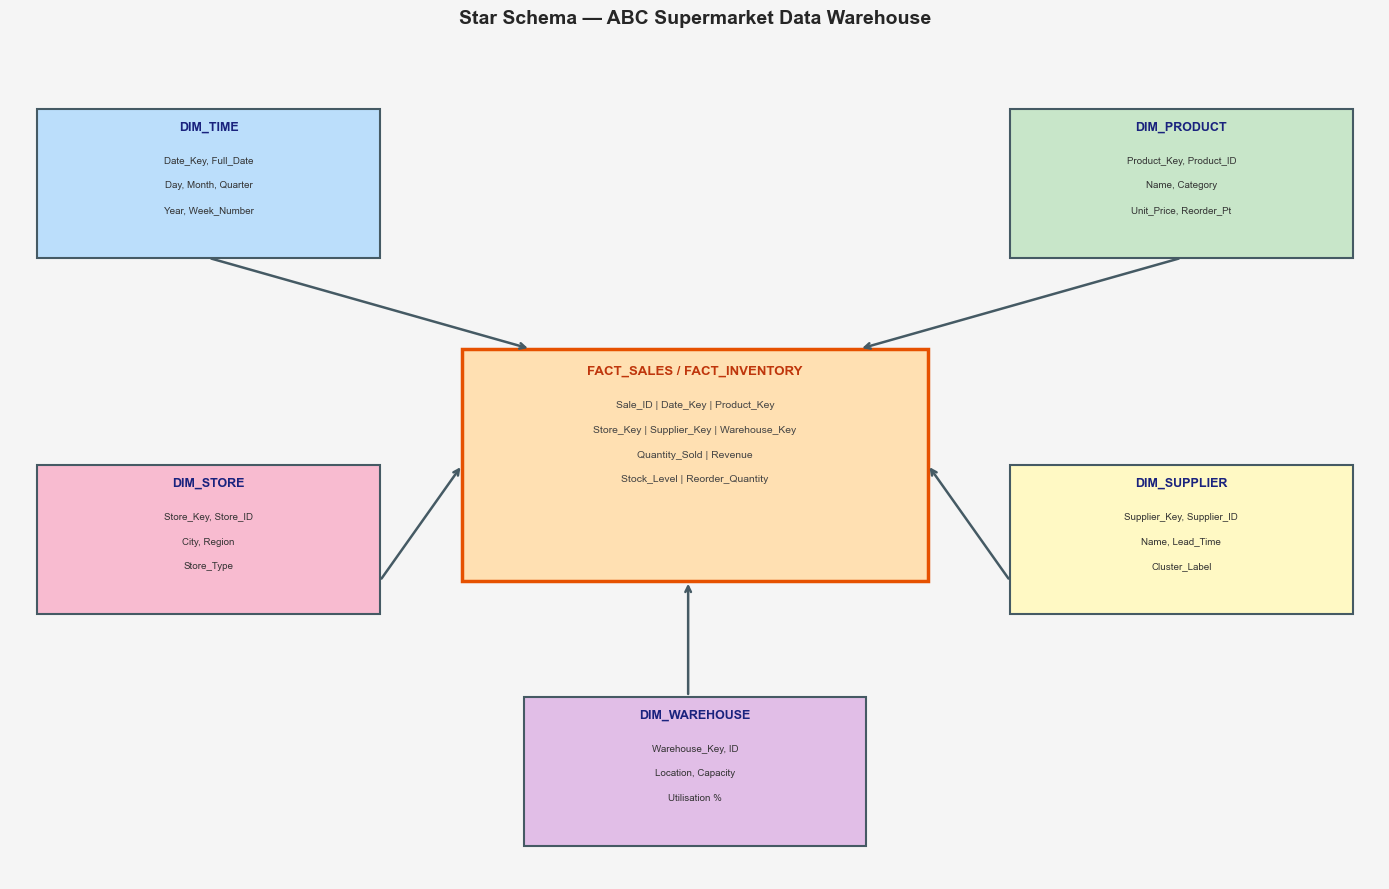

In [26]:
# Star Schema diagram
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_facecolor('#f5f5f5'); fig.patch.set_facecolor('#f5f5f5')
ax.set_title('Star Schema — ABC Supermarket Data Warehouse',
             fontsize=14, fontweight='bold', pad=20)

# Fact table
fact = plt.Rectangle((3.3, 3.6), 3.4, 2.8, fill=True,
                      facecolor='#ffe0b2', edgecolor='#e65100', linewidth=2.5)
ax.add_patch(fact)
ax.text(5, 6.1, 'FACT_SALES / FACT_INVENTORY',
        ha='center', fontsize=9.5, fontweight='bold', color='#bf360c')
for i, f in enumerate(['Sale_ID | Date_Key | Product_Key',
                        'Store_Key | Supplier_Key | Warehouse_Key',
                        'Quantity_Sold | Revenue',
                        'Stock_Level | Reorder_Quantity']):
    ax.text(5, 5.7 - i*0.3, f, ha='center', fontsize=7.5, color='#444')

dims = [
    {'name':'DIM_TIME',      'x':0.2,  'y':7.5, 'color':'#bbdefb',
     'fields':['Date_Key, Full_Date','Day, Month, Quarter','Year, Week_Number']},
    {'name':'DIM_PRODUCT',   'x':7.3,  'y':7.5, 'color':'#c8e6c9',
     'fields':['Product_Key, Product_ID','Name, Category','Unit_Price, Reorder_Pt']},
    {'name':'DIM_STORE',     'x':0.2,  'y':3.2, 'color':'#f8bbd0',
     'fields':['Store_Key, Store_ID','City, Region','Store_Type']},
    {'name':'DIM_SUPPLIER',  'x':7.3,  'y':3.2, 'color':'#fff9c4',
     'fields':['Supplier_Key, Supplier_ID','Name, Lead_Time','Cluster_Label']},
    {'name':'DIM_WAREHOUSE', 'x':3.75, 'y':0.4, 'color':'#e1bee7',
     'fields':['Warehouse_Key, ID','Location, Capacity','Utilisation %']},
]
for d in dims:
    r = plt.Rectangle((d['x'], d['y']), 2.5, 1.8, fill=True,
                       facecolor=d['color'], edgecolor='#455a64', linewidth=1.5)
    ax.add_patch(r)
    ax.text(d['x']+1.25, d['y']+1.55, d['name'],
            ha='center', fontsize=9, fontweight='bold', color='#1a237e')
    for i, f in enumerate(d['fields']):
        ax.text(d['x']+1.25, d['y']+1.15 - i*0.3, f,
                ha='center', fontsize=7, color='#333')

for (x1,y1),(x2,y2) in [((1.45,7.5),(3.8,6.4)), ((8.55,7.5),(6.2,6.4)),
                          ((2.7,3.6),(3.3,5.0)),  ((7.3,3.6),(6.7,5.0)),
                          ((4.95,2.2),(4.95,3.6))]:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', lw=1.8, color='#455a64'))
plt.tight_layout()
plt.show()


### Task 4.2 — ETL Pipeline

**EXTRACT** → **TRANSFORM** → **LOAD** — three explicit phases implemented below.


In [ ]:
# ══ PHASE 1: EXTRACT ══════════════════════════════════════════════════════════
print("PHASE 1: EXTRACT")
print("-" * 45)
raw_sales = sales_df.copy()
raw_inv   = inventory_df.copy()
raw_sup   = suppliers_df.copy()
raw_po    = purchase_orders_df.copy()
for name, df in [('Sales', raw_sales),('Inventory', raw_inv),
                  ('Suppliers', raw_sup),('Purchase Orders', raw_po)]:
    print(f"  {name:<20} : {len(df):,} rows extracted")

# ══ PHASE 2: TRANSFORM ════════════════════════════════════════════════════════
print("\nPHASE 2: TRANSFORM")
print("-" * 45)

raw_sales.drop_duplicates(inplace=True)
raw_inv.drop_duplicates(inplace=True)
raw_sales['Revenue']       = raw_sales['Revenue'].fillna(0)
raw_sales['Quantity_Sold'] = raw_sales['Quantity_Sold'].fillna(0)

# Dimension tables with surrogate keys
dim_product  = raw_sales[['Product_ID']].drop_duplicates().reset_index(drop=True)
dim_product['Product_Key'] = dim_product.index + 1

dim_store    = raw_sales[['Store_ID']].drop_duplicates().reset_index(drop=True)
dim_store['Store_Key'] = dim_store.index + 1

dim_supplier = raw_sup[['Supplier_ID','Supplier_Name',
                          'Lead_Time (days)','Order_Frequency']].drop_duplicates().reset_index(drop=True)
dim_supplier['Supplier_Key'] = dim_supplier.index + 1

dim_time = pd.DataFrame({'Full_Date': pd.date_range(
    raw_sales['Sale_Date'].min(), raw_sales['Sale_Date'].max())})
dim_time['Date_Key'] = dim_time['Full_Date'].dt.strftime('%Y%m%d').astype(int)
dim_time['Day']      = dim_time['Full_Date'].dt.day
dim_time['Month']    = dim_time['Full_Date'].dt.month
dim_time['Quarter']  = dim_time['Full_Date'].dt.quarter
dim_time['Year']     = dim_time['Full_Date'].dt.year

# Fact table
fact_sales = (raw_sales
    .merge(dim_product, on='Product_ID', how='left')
    .merge(dim_store,   on='Store_ID',   how='left')
    .merge(dim_time[['Full_Date','Date_Key']].rename(columns={'Full_Date':'Sale_Date'}),
        on='Sale_Date', how='left'))
fact_sales = fact_sales[['Sale_ID','Date_Key','Product_Key','Store_Key','Quantity_Sold','Revenue']]

for name, df in [('Dim_Product', dim_product),('Dim_Store', dim_store),
                ('Dim_Supplier', dim_supplier),('Dim_Time', dim_time),
                ('Fact_Sales', fact_sales)]:
    print(f"  {name:<20} built : {df.shape}")

# ══ PHASE 3: LOAD ══════════════════════════════════════════════════════════════
print("\nPHASE 3: LOAD")
print("-" * 45)
wh = sqlite3.connect(':memory:')
for name, df in [('Dim_Product', dim_product),('Dim_Store', dim_store),
                ('Dim_Supplier', dim_supplier),('Dim_Time', dim_time),
                ('Fact_Sales', fact_sales)]:
    df.to_sql(name, wh, index=False, if_exists='replace')
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {name}", wh)['n'][0]
    print(f"  Loaded {name:<20} : {n:,} rows")
print("\nETL pipeline complete.")


PHASE 1: EXTRACT
---------------------------------------------
  Sales                : 5,000 rows extracted
  Inventory            : 200 rows extracted
  Suppliers            : 50 rows extracted
  Purchase Orders      : 1,000 rows extracted

PHASE 2: TRANSFORM
---------------------------------------------
  Dim_Product          built : (5, 2)
  Dim_Store            built : (4, 2)
  Dim_Supplier         built : (50, 5)
  Dim_Time             built : (5000, 6)
  Fact_Sales           built : (5000, 6)

PHASE 3: LOAD
---------------------------------------------
  Loaded Dim_Product          : 5 rows
  Loaded Dim_Store            : 4 rows
  Loaded Dim_Supplier         : 50 rows
  Loaded Dim_Time             : 5,000 rows
  Loaded Fact_Sales           : 5,000 rows

ETL pipeline complete.


### Task 4.3 — Aggregation Strategy

Three pre-aggregated reporting tables for fast dashboard queries.


In [28]:
# 1. Monthly Sales Summary
print("=" * 60)
print("  TABLE 1: Monthly_Sales_Summary")
print("=" * 60)
monthly_summary = (sales_df
    .groupby(['Product_ID', sales_df['Sale_Date'].dt.to_period('M').rename('Month')])
    .agg(Total_Qty=('Quantity_Sold','sum'),
         Total_Revenue=('Revenue','sum'),
         Transactions=('Sale_ID','count'))
    .reset_index())
monthly_summary['Month']     = monthly_summary['Month'].astype(str)
monthly_summary['Avg_Price'] = (monthly_summary['Total_Revenue'] / monthly_summary['Total_Qty']).round(2)
print(f"Rows: {len(monthly_summary):,}  (vs {len(sales_df):,} raw rows — {len(sales_df)/len(monthly_summary):.1f}x compression)")
display(monthly_summary.head(8))

# 2. Product Turnover
print("\n" + "=" * 60)
print("  TABLE 2: Product_Turnover  (Sales / Avg Stock)")
print("=" * 60)
total_qty = sales_df.groupby('Product_ID')['Quantity_Sold'].sum().reset_index()
avg_stock = inventory_df.groupby('Product_ID')['Stock_Level'].mean().reset_index()
turnover  = total_qty.merge(avg_stock, on='Product_ID')
turnover.columns = ['Product_ID','Total_Sales_Qty','Avg_Stock_Level']
turnover['Turnover_Ratio'] = (turnover['Total_Sales_Qty'] / turnover['Avg_Stock_Level']).round(2)
turnover = turnover.sort_values('Turnover_Ratio', ascending=False)
print(turnover.to_string(index=False))
print("(Higher = faster stock movement = more efficient inventory)")

# 3. Supplier Performance
print("\n" + "=" * 60)
print("  TABLE 3: Supplier_Performance_Summary")
print("=" * 60)
purchase_orders_df['Actual_LT'] = ((purchase_orders_df['Arrival_Date']
                                    - purchase_orders_df['Order_Date']).dt.days)
sup_perf = (purchase_orders_df.groupby('Supplier_ID')
    .agg(Avg_Lead_Time=('Actual_LT','mean'),
         Std_Lead_Time=('Actual_LT','std'),
         Total_Orders=('Order_ID','count'),
         Total_Qty_Supplied=('Quantity','sum'))
    .round(2).reset_index())
# Note: Std is 0 because all actual lead times in this dataset are 5 days
sup_perf['Reliability'] = sup_perf['Std_Lead_Time'].apply(
    lambda s: 'Consistent' if s == 0 or pd.isna(s) else 'Variable')
display(sup_perf.head(10))


  TABLE 1: Monthly_Sales_Summary
Rows: 823  (vs 5,000 raw rows — 6.1x compression)


,Product_ID,Month,Total_Qty,Total_Revenue,Transactions,Avg_Price
0,P001,2024-01,902,97996,4,108.64
1,P001,2024-02,1322,158814,5,120.13
2,P001,2024-03,3243,348879,12,107.58
3,P001,2024-04,2239,187431,7,83.71
4,P001,2024-05,1266,120507,5,95.19
5,P001,2024-06,269,28852,1,107.26
6,P001,2024-07,1051,153521,5,146.07
7,P001,2024-08,1349,129621,6,96.09



  TABLE 2: Product_Turnover  (Sales / Avg Stock)
Product_ID  Total_Sales_Qty  Avg_Stock_Level  Turnover_Ratio
      P005           254794       195.294118         1304.67
      P004           258635       221.666667         1166.77
      P001           260296       231.225000         1125.73
      P003           249297       225.117647         1107.41
      P002           269100       247.205128         1088.57
(Higher = faster stock movement = more efficient inventory)

  TABLE 3: Supplier_Performance_Summary


,Supplier_ID,Avg_Lead_Time,Std_Lead_Time,Total_Orders,Total_Qty_Supplied,Reliability
0,SUP001,5.0,0.0,18,5328,Consistent
1,SUP002,5.0,0.0,21,6016,Consistent
2,SUP003,5.0,0.0,22,5521,Consistent
3,SUP004,5.0,0.0,25,6927,Consistent
4,SUP005,5.0,0.0,27,7981,Consistent
5,SUP006,5.0,0.0,14,4498,Consistent
6,SUP007,5.0,0.0,19,5620,Consistent
7,SUP008,5.0,0.0,33,9350,Consistent
8,SUP009,5.0,0.0,15,3780,Consistent
9,SUP010,5.0,0.0,20,6451,Consistent


## 5. Business Insights & Recommendations

Translating every analytical finding into decisions for management.


In [29]:
print("=" * 68)
print("  KEY FINDINGS - ABC SUPERMARKET SUPPLY CHAIN ANALYSIS")
print("=" * 68)

fast_p = product_movement[product_movement['Sales_Category']=='Fast Moving']['Product_ID'].tolist()
slow_p = product_movement[product_movement['Sales_Category']=='Slow Moving']['Product_ID'].tolist()
mod_p  = product_movement[product_movement['Sales_Category']=='Moderate']['Product_ID'].tolist()
print("\n1. PRODUCT MOVEMENT (last 3 months)")
print(f"   Fast Moving : {fast_p} -> increase stock and reorder frequency")
print(f"   Moderate    : {mod_p}")
print(f"   Slow Moving : {slow_p} -> reduce order qty; overstock risk")

crit = restock_report[restock_report['Stock_Status']=='Critical']
low  = restock_report[restock_report['Stock_Status']=='Low Stock']
pct  = len(restock_report) / len(inventory_df) * 100
print("\n2. STOCK HEALTH")
print(f"   {pct:.1f}% of inventory records are below reorder level")
print(f"   Critical (stock < 50% threshold) : {len(crit)} store-product combinations")
print(f"   Low Stock alerts                 : {len(low)}")
if not crit.empty:
    print(f"   Products needing immediate action: {crit['Product_ID'].unique().tolist()}")

total_fc = forecast_by_product["Monthly_Forecast"].sum()
top_p    = forecast_by_product.iloc[0]
print("\n3. DEMAND FORECAST (Next 30 Days — Linear Regression)")
print(f"   Total forecast across all products : {total_fc:,.0f} units")
print(f"   Highest demand product             : {top_p['Product_ID']} ({top_p['Monthly_Forecast']:,.0f} units)")
print(f"   Model R2                           : {r2:.4f}")
for _, row in forecast_by_product.iterrows():
    print(f"   {row['Product_ID']:6s}: {row['Monthly_Forecast']:,.0f} units forecast")

needs_raise = reorder_df[reorder_df['Adjustment'] > 10]
needs_lower = reorder_df[reorder_df['Adjustment'] < -10]
print("\n4. REORDER POINT OPTIMISATION")
for _, r in needs_raise.iterrows():
    print(f"   {r['Product_ID']}: RAISE by {r['Adjustment']:.0f} units (current: {r['Current_RL']:.0f} -> optimal: {r['Final_ROP']:.0f})")
for _, r in needs_lower.iterrows():
    print(f"   {r['Product_ID']}: LOWER by {abs(r['Adjustment']):.0f} units (overstock risk)")
if needs_raise.empty and needs_lower.empty:
    print("   All reorder levels within acceptable range.")

hr = supplier_ranking[supplier_ranking['Supplier_Category']=='High Risk']
ef = supplier_ranking[supplier_ranking['Supplier_Category']=='Efficient']
print("\n5. SUPPLIER PERFORMANCE")
print(f"   High-Risk suppliers (avg LT > 7 days) : {len(hr)}")
print(f"   Efficient suppliers                   : {len(ef)}")
print(f"   Avg lead time across all suppliers    : {suppliers_df['Lead_Time (days)'].mean():.1f} days")
if not hr.empty:
    w = hr.iloc[0]
    print(f"   Slowest: {w['Supplier_ID']} at {w['Avg_Lead_Time']:.1f} days -> review contract")

print("\n6. SUPPLIER SEGMENTS (K-Means Clustering)")
for lbl in ["Fast (Low Lead Time)", "Standard", "Slow (High Lead Time)"]:
    g = sup_c[sup_c["Cluster_Label"]==lbl]
    print(f"   {lbl}: {len(g)} suppliers | avg LT {g['Lead_Time (days)'].mean():.1f} days")

print("\n" + "=" * 68)
print("  RECOMMENDED ACTIONS")
print("=" * 68)
for a in [
    "1. Immediately restock Critical-flagged products to prevent stockouts.",
    "2. Reduce order quantities for Slow Moving products to free up capital.",
    "3. Update reorder point thresholds to the calculated Final_ROP values.",
    "4. Re-negotiate or replace High-Risk suppliers (avg LT > 7 days).",
    "5. Prioritise Fast cluster suppliers for urgent purchase orders.",
    "6. Schedule monthly review of the Product Turnover table.",
]:
    print(f"   {a}")
print("\n" + "=" * 68)
print("  CASE STUDY COMPLETE")
print("=" * 68)


  KEY FINDINGS - ABC SUPERMARKET SUPPLY CHAIN ANALYSIS

1. PRODUCT MOVEMENT (last 3 months)
   Fast Moving : ['P004'] -> increase stock and reorder frequency
   Moderate    : ['P003', 'P002']
   Slow Moving : ['P005', 'P001'] -> reduce order qty; overstock risk

2. STOCK HEALTH
   26.5% of inventory records are below reorder level
   Critical (stock < 50% threshold) : 25 store-product combinations
   Low Stock alerts                 : 28
   Products needing immediate action: ['P005', 'P004', 'P001', 'P003', 'P002']

3. DEMAND FORECAST (Next 30 Days — Linear Regression)
   Total forecast across all products : 38,820 units
   Highest demand product             : P002 (8,248 units)
   Model R2                           : 0.0002
   P002  : 8,248 units forecast
   P004  : 8,002 units forecast
   P005  : 7,866 units forecast
   P003  : 7,483 units forecast
   P001  : 7,221 units forecast

4. REORDER POINT OPTIMISATION
   P001: RAISE by 155 units (current: 132 -> optimal: 287)
   P002: RAISE 

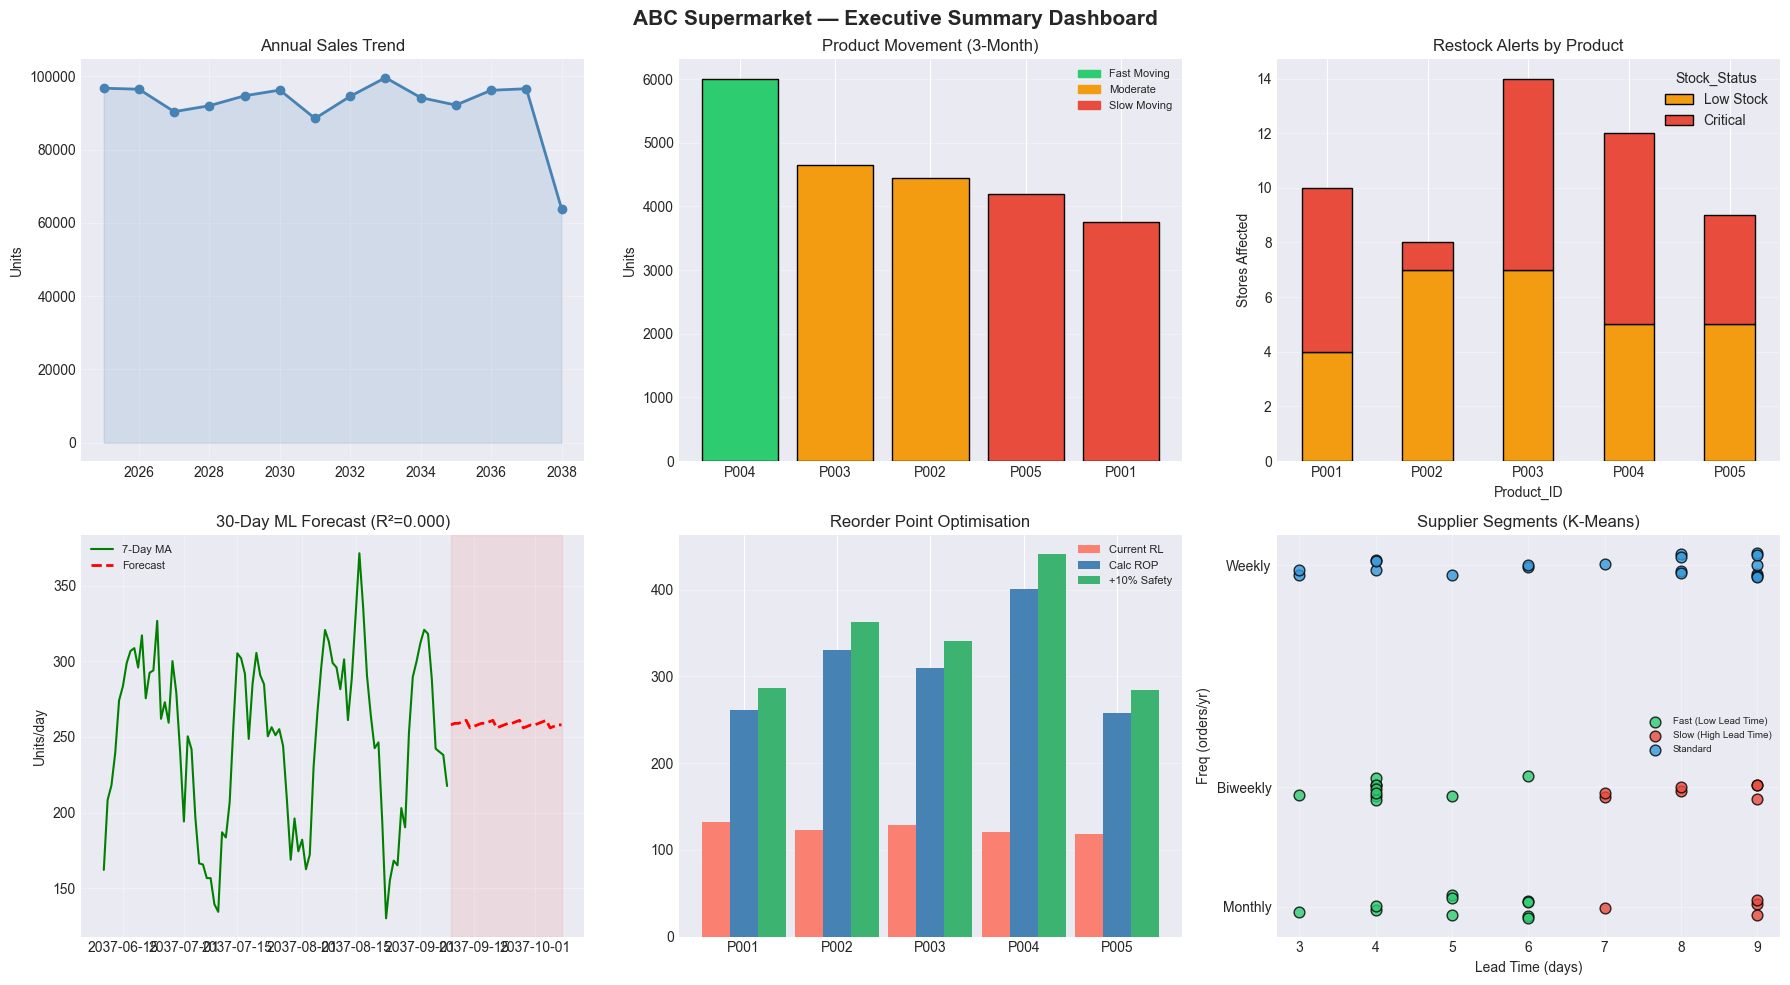

In [30]:
# Executive summary — 6-panel dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ABC Supermarket — Executive Summary Dashboard', fontsize=15, fontweight='bold')

# 1. Annual sales trend
ann = sales_df.set_index('Sale_Date').resample('YE')['Quantity_Sold'].sum()
axes[0,0].plot(ann.index, ann.values, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(ann.index, ann.values, alpha=0.15, color='steelblue')
axes[0,0].set_title('Annual Sales Trend'); axes[0,0].set_ylabel('Units')
axes[0,0].grid(True, alpha=0.3)

# 2. Product movement (3 months)
bar_c2 = [cat_colors.get(c,'grey') for c in product_movement['Sales_Category']]
axes[0,1].bar(product_movement['Product_ID'], product_movement['Total_Sales'],
              color=bar_c2, edgecolor='black')
handles2 = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
axes[0,1].legend(handles=handles2, fontsize=8)
axes[0,1].set_title('Product Movement (3-Month)'); axes[0,1].set_ylabel('Units')
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Restock severity by product
alert_c = (restock_report.groupby(['Product_ID','Stock_Status'])
           .size().unstack(fill_value=0))
for col in ['Critical','Low Stock']:
    if col not in alert_c.columns:
        alert_c[col] = 0
alert_c[['Low Stock','Critical']].plot(kind='bar', stacked=True, ax=axes[0,2],
    color=['#f39c12','#e74c3c'], edgecolor='black')
axes[0,2].set_title('Restock Alerts by Product'); axes[0,2].set_ylabel('Stores Affected')
axes[0,2].tick_params(axis='x', rotation=0); axes[0,2].grid(axis='y', alpha=0.3)

# 4. ML forecast (recent window)
recent_h = daily_sales[daily_sales['Sale_Date'] >= daily_sales['Sale_Date'].max() - pd.Timedelta(days=90)]
axes[1,0].plot(recent_h['Sale_Date'], recent_h['MA_7'], color='green', linewidth=1.5, label='7-Day MA')
axes[1,0].plot(forecast_df['Date'], forecast_df['Predicted_Qty'],
               color='red', linewidth=2, linestyle='--', label='Forecast')
axes[1,0].axvspan(forecast_df['Date'].min(), forecast_df['Date'].max(), alpha=0.07, color='red')
axes[1,0].set_title(f'30-Day ML Forecast (R²={r2:.3f})')
axes[1,0].set_ylabel('Units/day'); axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)

# 5. Reorder point comparison
x2 = np.arange(len(reorder_df)); w = 0.3
axes[1,1].bar(x2-w, reorder_df['Current_RL'],    w, label='Current RL',  color='salmon')
axes[1,1].bar(x2,   reorder_df['Reorder_Point'],  w, label='Calc ROP',   color='steelblue')
axes[1,1].bar(x2+w, reorder_df['Final_ROP'],      w, label='+10% Safety',color='mediumseagreen')
axes[1,1].set_xticks(x2); axes[1,1].set_xticklabels(reorder_df['Product_ID'])
axes[1,1].set_title('Reorder Point Optimisation')
axes[1,1].legend(fontsize=8); axes[1,1].grid(axis='y', alpha=0.3)

# 6. Supplier clusters (with jitter)
np.random.seed(42)
for lbl, grp in sup_c.groupby('Cluster_Label'):
    jitter = np.random.uniform(-1.5, 1.5, size=len(grp))
    axes[1,2].scatter(grp['Lead_Time (days)'], grp['Freq_Num'] + jitter,
                      c=palette[lbl], label=lbl, s=60, alpha=0.8, edgecolors='black')
axes[1,2].set_xlabel('Lead Time (days)'); axes[1,2].set_ylabel('Freq (orders/yr)')
axes[1,2].set_yticks([12,26,52]); axes[1,2].set_yticklabels(['Monthly','Biweekly','Weekly'])
axes[1,2].set_title('Supplier Segments (K-Means)')
axes[1,2].legend(fontsize=7); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
